## Desertification Rate

### 🏜️ What Is Desertification Rate?

The **Desertification Rate** refers to the **speed at which fertile land becomes degraded into desert**. It is typically caused by factors such as **climate change**, **deforestation**, **unsustainable agriculture**, and **overgrazing**.

Understanding this rate is crucial to evaluate the **progression of land degradation**, especially in arid, semi-arid, and dry sub-humid areas.

---

### 📊 Key Metrics to Analyze Desertification

To assess the desertification rate, researchers analyze a combination of **climatic, ecological, and human impact indicators**, such as:

- **Rainfall trends** (decreasing precipitation = higher risk)
- **Temperature anomalies** (increased heat accelerates soil degradation)
- **Soil erosion** rates
- **Vegetation cover** (loss of green cover over time)
- **Normalized Difference Vegetation Index (NDVI)** from satellite data
- **Land use and land cover changes (LULC)**
- **Drought frequency and severity**
- **Population pressure** and **land exploitation levels**

---

### 📈 Why It Matters

- Affects **agriculture** and **food security**
- Increases **climate vulnerability**
- Triggers **forced migration**
- Threatens **biodiversity**

Monitoring the desertification rate helps inform **sustainable land management policies** and **adaptation strategies** for vulnerable regions.





📘 What is ET₀ (Potential Evapotranspiration)?
ET₀ represents the potential amount of water that could be evaporated and transpired from a reference surface (usually grass) under ideal conditions — meaning:

Full vegetation cover

Unlimited water availability

No water stress

It is not the actual evapotranspiration observed in the environment, but rather a standardized climatic baseline that helps compare regions fairly.

🌡️ Why Use ET₀ in Aridity Analysis?
The UNCCD and UNEP define the Aridity Index (AI) as:

#### AI
=
Precipitation (P)
Potential Evapotranspiration (ET₀)
AI= 
Potential Evapotranspiration (ET₀)
Precipitation (P)
​
 
This ratio helps evaluate how dry a region’s climate is, independent of land use or irrigation practices.

🧮 In This Project:
We used ET₀ = 1463.82 mm/year, computed from the Global Aridity and PET Database v2 (Trabucco & Zomer, 2018).

This value represents the mean annual PET over Australia, based on the FAO Penman-Monteith method.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data"
OUTPUTS_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\outputs"

In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, "rainfall", "Australia_Annual_TotalRainfall__BoM_.csv"))

In [5]:
# Average Evotranspiration from et0_yr.tif.xml (../data/desertification/et0_yr.tif.xml)
mean_et0 = 1463.82 # mm/year

In [6]:
# Aridity Index calculation
# Aridity Index = P/PET, where P is rainfall and PET is potential evapotrans
df["Aridity Index (P/PET)"] = df["Rainfall (mm)"] / mean_et0

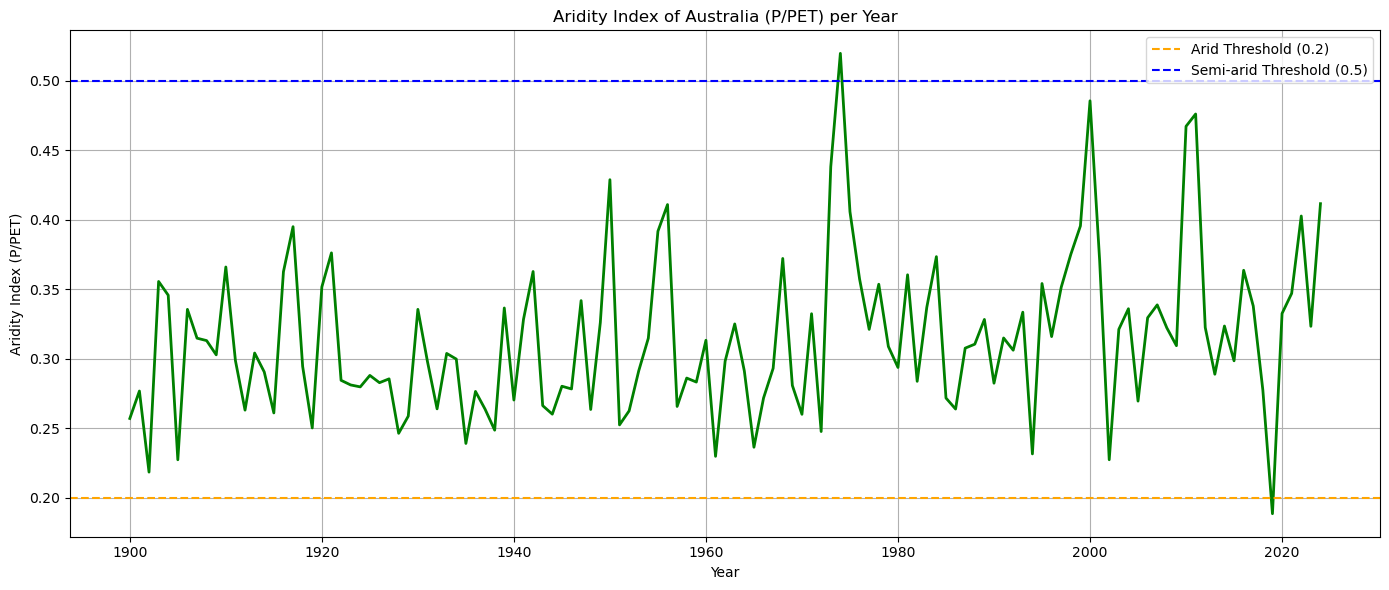

In [7]:
#Ploting Aridity Index over time
plt.figure(figsize=(14, 6))
plt.plot(df["Year"], df["Aridity Index (P/PET)"], color="green", linewidth=2)
plt.axhline(0.2, color="orange", linestyle="--", label="Arid Threshold (0.2)")
plt.axhline(0.5, color="blue", linestyle="--", label="Semi-arid Threshold (0.5)")
plt.title("Aridity Index of Australia (P/PET) per Year")
plt.xlabel("Year")
plt.ylabel("Aridity Index (P/PET)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "aridity_index_australia.png"), dpi=300)
plt.show()

## Now We should take a look to Vegetation Condition

### 🌿 Vegetation Condition: NDVI or Land Productivity Trend

To understand desertification, it's critical to evaluate how vegetation responds to long-term climate stress. A key indicator for this is **NDVI** (Normalized Difference Vegetation Index), which measures the "greenness" or density of vegetation using satellite imagery.

#### ✅ Why NDVI?
- NDVI ranges from **-1 to +1**
  - Values near **0.3–0.8** → healthy vegetation
  - Values near **0–0.2** → sparse or degraded vegetation
- NDVI helps detect:
  - **Vegetation stress or recovery**
  - **Long-term degradation trends**
  - **Impact of droughts and aridity**

#### 🌱 Alternative Indicator: Land Productivity Dynamics
Some institutions like UNCCD also track **land productivity trends** using satellite vegetation models:
- Stable productivity
- Declining productivity
- Early signs of degradation

#### 🧭 Goal for This Step
- Obtain a time series of **NDVI or vegetation productivity** from ~1980 to today
- Compute **national averages per year**
- Compare trends to Rainfall and Aridity Index


In [8]:
ndvi_df = pd.read_csv(os.path.join(DATA_DIR, "desertificationRate", "Australia_annual_ndvi.csv"))

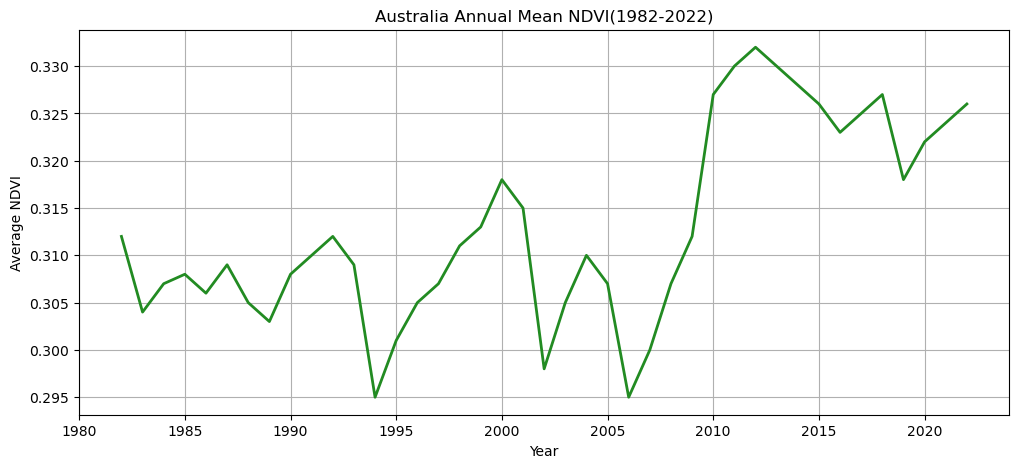

In [9]:
# Plotting the Normalized Difference Vegetation Index
plt.figure(figsize=(12, 5))
plt.plot(ndvi_df["Year"], ndvi_df["Mean_NDVI"], color="forestgreen", lw=2)
plt.title("Australia Annual Mean NDVI(1982-2022)")
plt.xlabel("Year")
plt.ylabel("Average NDVI")
plt.grid(True)
plt.savefig(os.path.join(OUTPUTS_DIR, "ndvi_index_australia.png"), dpi=300)
plt.show()

In [11]:
# Needed NDVI data, rainfall dataset and aridity index to get Desertification rate
import pandas as pd

ndvi_df = pd.read_csv(os.path.join(DATA_DIR, "desertificationRate", "Australia_annual_ndvi.csv"))

rainfall_df = pd.read_csv(os.path.join(DATA_DIR, "rainfall", "Australia_Rainfall_Combined.csv"))

mean_et0 = 1463.82 # mm/year

if "Aridity Index (P/PET)" not in rainfall_df.columns:
    rainfall_df["Aridity Index (P/PET)"] = rainfall_df["Rainfall (mm)"] / mean_et0


# Merge the datasets
merged_df = pd.merge(rainfall_df, ndvi_df, on="Year", how="inner") 

# Select and rename key columns for clarity
final_df = merged_df[[
    "Year",
    "Rainfall (mm)",
    "Rainfall Anomaly (mm)",
    "Aridity Index (P/PET)",
    "Mean_NDVI"
]]

# Save to CSV
final_df.to_csv(os.path.join(DATA_DIR, "desertificationRate", "australia_desertification_indicators.csv"), index=False)

In [12]:
# Getting Desertification Rate (Proxy Method)

"""Proxy Method: is a technique used when direct data (e.g. official maps of degraded land) is missing.
      It uses indirect indicators — like climate dryness and vegetation loss — to approximate the occurrence or trend of desertification.
"""

# Define climate stress condition: arid and vegetation stress
merged_df["Climate Stress Year"] = (merged_df["Aridity Index (P/PET)"] < 0.2) & (merged_df["Mean_NDVI"] < 0.3)

# Calculate proxy desertification rate
total_years = len(merged_df)
stress_years = merged_df["Climate Stress Year"].sum()
desertification_rate = round((stress_years / total_years) * 100, 2)

# Output summary
summary = pd.DataFrame([{
    "Years Analyzed": total_years,
    "Stress Years (Aridity Index<0.2 & NDVI<0.3)": stress_years,
    "Estimated Desertification Rate (% of years)": desertification_rate
}])

print(summary)

   Years Analyzed  Stress Years (Aridity Index<0.2 & NDVI<0.3)  \
0              41                                            0   

   Estimated Desertification Rate (% of years)  
0                                          0.0  


### 🌵 Interpretation: Desertification Stress Threshold (Proxy Method)

Although some years show signs of drought (low precipitation and aridity) or vegetation decline (low NDVI), **none of the years between 1982 and 2022 meet both criteria simultaneously** at the national scale.

This suggests that, based on our proxy definition (AI < 0.2 and NDVI < 0.3), **Australia has not experienced an extreme desertification year** across the whole country during this period.

However, this does not rule out regional degradation. It is important to complement this analysis with official land degradation metrics.

📌 According to the **UNCCD**, Australia's degraded land area increased from **7.0 % in 1997** to **8.19 % in 2019**, implying an estimated **+0.054 % per year** degradation rate.


**References – UNCCD National Reports on Land Degradation**

- Australia (2000). *Australian Actions to Combat Desertification and Land Degradation* (UNCCD Report, 2000).
- Australia (2002). *DCP – 2002: National Report to UNCCD*.  
- Government of Australia. (2010). Performance Review Submission.
- 🌍 UNCCD PRAIS Dashboard: https://data.unccd.int
→ Search for Australia → See degradation indicators

These reports are public and part of the UNCCD’s periodic national submissions. The PRAIS system aggregates these metrics for visualization and download.

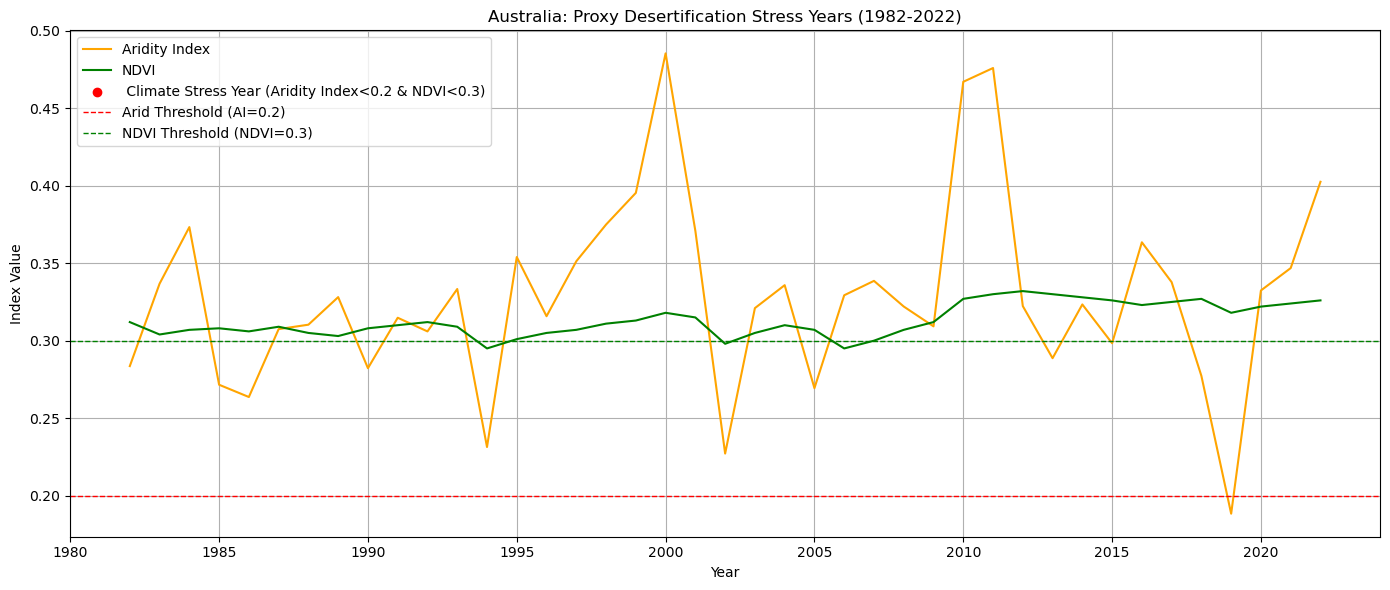

In [13]:
# Plotting 

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(merged_df["Year"], merged_df["Aridity Index (P/PET)"], label="Aridity Index", color="orange")
plt.plot(merged_df["Year"], merged_df["Mean_NDVI"], label="NDVI", color="green")

# Highlight stress years
stress_years = merged_df[merged_df["Climate Stress Year"] == True]
plt.scatter(stress_years["Year"], stress_years["Aridity Index (P/PET)"], color="red", label=" Climate Stress Year (Aridity Index<0.2 & NDVI<0.3)", zorder=5)

# Add thresholds
plt.axhline(0.2, color="red", linestyle="--", linewidth=1, label="Arid Threshold (AI=0.2)")
plt.axhline(0.3, color="green", linestyle="--", linewidth=1, label="NDVI Threshold (NDVI=0.3)")

# Labels and formatting
plt.title("Australia: Proxy Desertification Stress Years (1982-2022)")
plt.xlabel("Year")
plt.ylabel("Index Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "desertificationRate_with_mergedParams_AI_NDVI.png"), dpi=300)
plt.show()

### 🧠 Interpretation

- Across 1982–2022, **no year met both thresholds simultaneously** at the national scale.
- While several years show **climate stress** (e.g., 2002, 2019), vegetation remained above the NDVI danger zone.
- This suggests that **Australia, as a whole**, has not crossed into **extreme desertification** conditions during this period.

---

### ⚠️ Should We Be Worried?

- **Not immediately**, at the national level.
- However:
  - **Aridity Index has approached the threshold** in some years
  - **NDVI shows signs of variability and decline** during droughts
- Combined with UNCCD data showing an increase from **7.0 % to 8.19 % degraded land (1997–2019)**, this suggests a **slow but steady degradation trend**.

📌 Desertification may not be dramatic year-to-year, but it **accumulates gradually** — especially in arid and semi-arid zones. Regional or local analysis may reveal more critical hotspots.
